In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df= pd.read_csv('train.csv')

In [71]:
df

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Transported,Deck,Num,Side
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,False,B,0.0,P
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,True,F,0.0,S
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,False,A,0.0,S
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,False,A,0.0,S
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,True,F,1.0,S
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8688,9276_01,Europa,False,A/98/P,55 Cancri e,41.0,True,0.0,6819.0,0.0,1643.0,74.0,False,A,98.0,P
8689,9278_01,Earth,True,G/1499/S,PSO J318.5-22,18.0,False,0.0,0.0,0.0,0.0,0.0,False,G,1499.0,S
8690,9279_01,Earth,False,G/1500/S,TRAPPIST-1e,26.0,False,0.0,0.0,1872.0,1.0,0.0,True,G,1500.0,S
8691,9280_01,Europa,False,E/608/S,55 Cancri e,32.0,False,0.0,1049.0,0.0,353.0,3235.0,False,E,608.0,S


In [4]:
df.columns

Index(['PassengerId', 'HomePlanet', 'CryoSleep', 'Cabin', 'Destination', 'Age',
       'VIP', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck',
       'Name', 'Transported'],
      dtype='object')

In [23]:
df['HomePlanet'].value_counts()

HomePlanet
Earth     4602
Europa    2131
Mars      1759
Name: count, dtype: int64

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   object 
 1   HomePlanet    8492 non-null   object 
 2   CryoSleep     8476 non-null   object 
 3   Cabin         8494 non-null   object 
 4   Destination   8511 non-null   object 
 5   Age           8514 non-null   float64
 6   VIP           8490 non-null   object 
 7   RoomService   8512 non-null   float64
 8   FoodCourt     8510 non-null   float64
 9   ShoppingMall  8485 non-null   float64
 10  Spa           8510 non-null   float64
 11  VRDeck        8505 non-null   float64
 12  Name          8493 non-null   object 
 13  Transported   8693 non-null   bool   
dtypes: bool(1), float64(6), object(7)
memory usage: 891.5+ KB
None


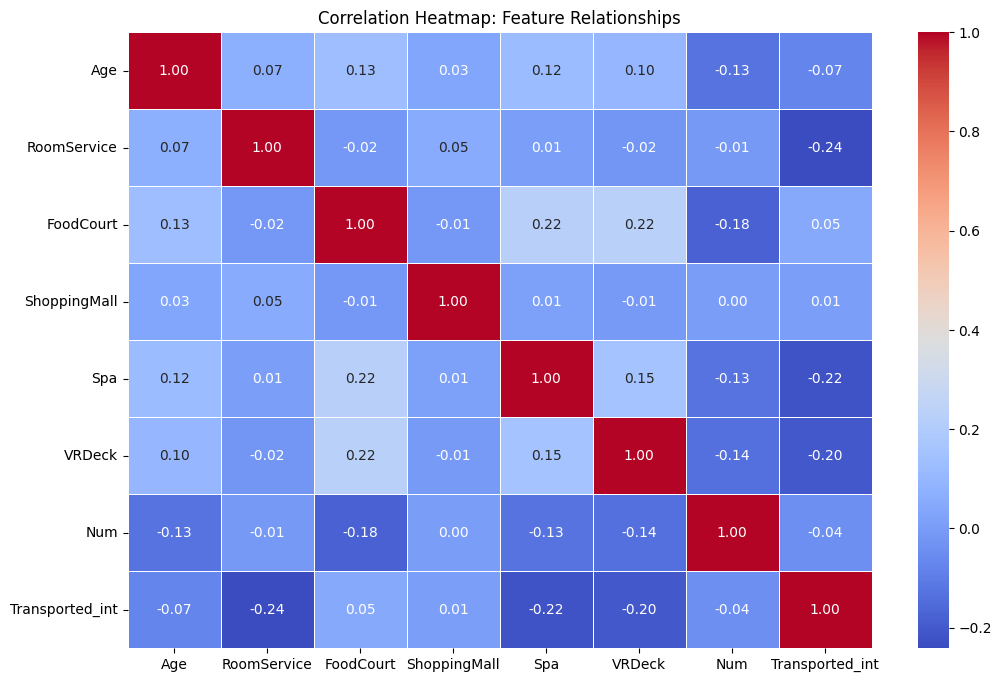

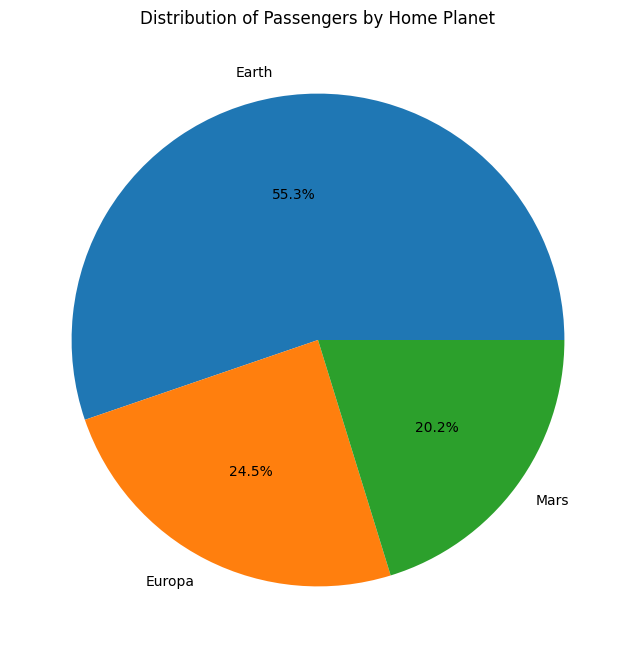

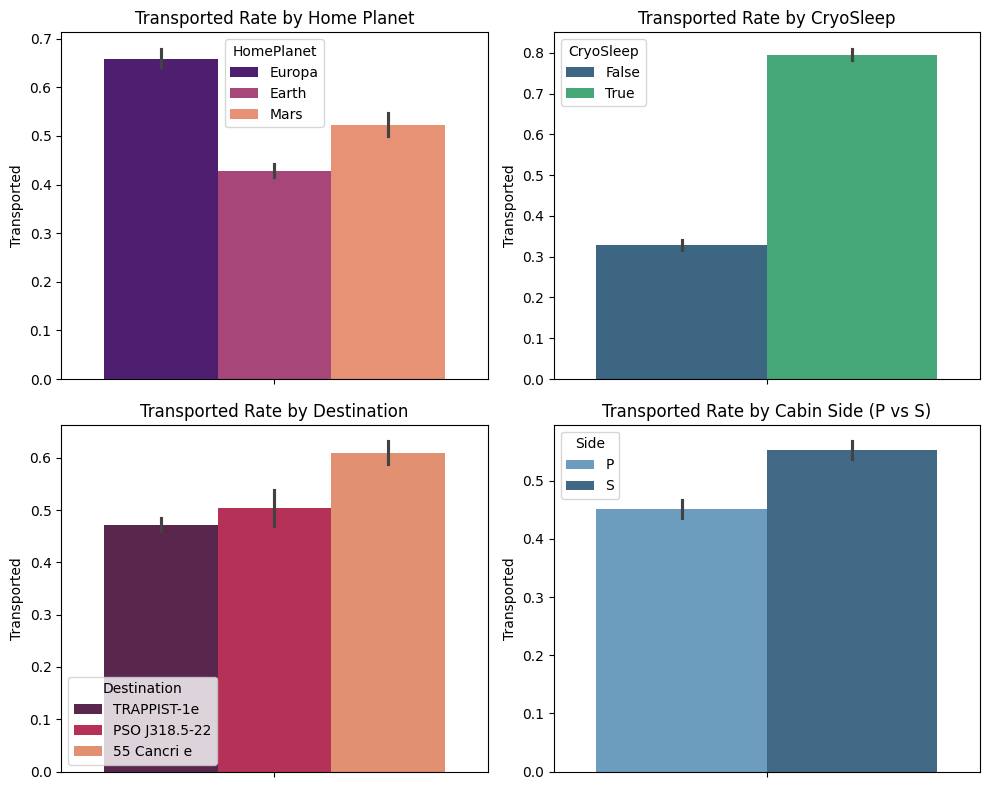

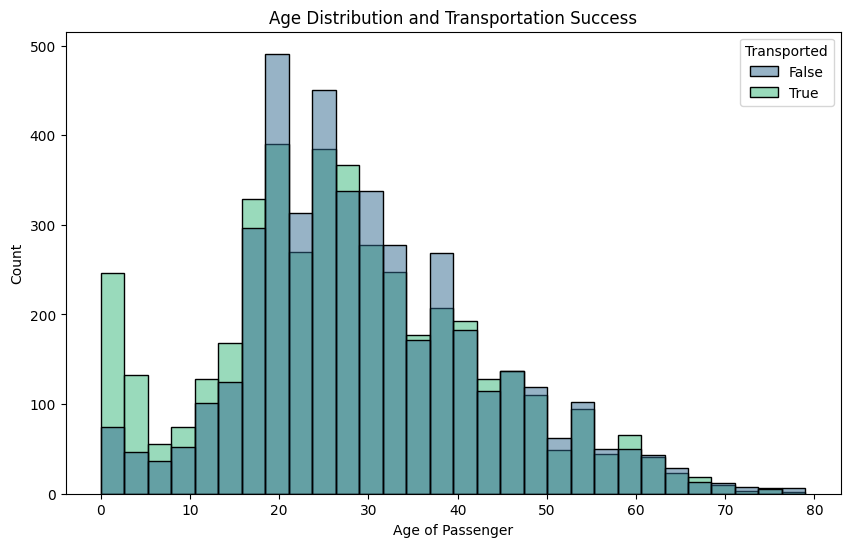

In [110]:
#lets first import the libraries we will use:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
#lets call the dataset:
df=pd.read_csv('train.csv')
#general info about the dataset
print(df.info())
#since we have quite abit of null values, lets replace them
Homeplanet= df['HomePlanet'].value_counts().index[0]
df['HomePlanet']= df['HomePlanet'].fillna(Homeplanet) #to deal with nan, we will replace with most common planet
df['CryoSleep'] = df['CryoSleep'].astype(bool) #just to make the error warning go away
Cryosleep=df['CryoSleep'].value_counts().index[0]
df['CryoSleep']=df['CryoSleep'].fillna(Cryosleep) #to deal with nan, we will replace with most common status
df[['Deck', 'Num', 'Side']] = df['Cabin'].str.split('/', expand=True) #To analyse data of cabin better
most_common_deck = df['Deck'].value_counts().index[0]
df['Deck'] = df['Deck'].fillna(most_common_deck)
most_common_side = df['Side'].value_counts().index[0]
df['Side'] = df['Side'].fillna(most_common_side)
df['Num'] = pd.to_numeric(df['Num'])
df['Num'] = df['Num'].fillna(df['Num'].median()) # it's better to use the median since it's a numeric-like value
destination=df['Destination'].value_counts().index[0]
df['Destination']=df['Destination'].fillna(destination)
df['Age']=df['Age'].fillna(df['Age'].median())
df['VIP'] = df['VIP'].astype(bool)
vip=df['VIP'].value_counts().index[0]
df['VIP']=df['VIP'].fillna(vip)
df['RoomService'] = df['RoomService'].fillna(df['RoomService'].median())
df['FoodCourt'] = df['FoodCourt'].fillna(df['FoodCourt'].median())
df['ShoppingMall'] = df['ShoppingMall'].fillna(df['ShoppingMall'].median())
df['VRDeck'] = df['VRDeck'].fillna(df['VRDeck'].median())
df=df.drop('Name',axis=1)
#we finished cleaning, lets save the cleaned df.
df_clean= df.copy()
df['Transported_int'] = df['Transported'].astype(int)

#HEATMAP
corr_matrix = df.select_dtypes(include=['number']).corr()
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap: Feature Relationships')
plt.show()

#PIE CHART -Distribution of Passengers by Home Planet
plt.figure(figsize=(8, 8))
planet_counts = df['HomePlanet'].value_counts()
plt.pie(planet_counts, labels=planet_counts.index, autopct='%1.1f%%')
plt.title('Distribution of Passengers by Home Planet')
plt.show()

#BAR PLOT- Transported by HomePlanet
plt.figure(figsize=(10,8))
plt.subplot(2, 2, 1)
sns.barplot(data=df,hue='HomePlanet',legend=True, y='Transported',palette='magma')
plt.title('Transported Rate by Home Planet')
#BAR PLOT- Transported by CryoSleep
plt.subplot(2, 2, 2)
sns.barplot(data=df,hue='CryoSleep',legend=True, y='Transported',palette='viridis')
plt.title('Transported Rate by CryoSleep')
#BAR PLOT- Transported Rate Destination
plt.subplot(2, 2, 3)
sns.barplot(data=df,hue='Destination',legend=True, y='Transported',palette='rocket')
plt.title('Transported Rate by Destination')
# BAR PLOT- Transported by Cabin Side (Port vs Starboard)
plt.subplot(2, 2, 4)
sns.barplot(data=df, hue='Side',legend=True, y='Transported',palette='Blues_d')
plt.title('Transported Rate by Cabin Side (P vs S)')
plt.tight_layout()

#HISTOGRAM - age distribution
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='Age', hue='Transported', bins=30, palette='viridis')

plt.title('Age Distribution and Transportation Success')
plt.xlabel('Age of Passenger')
plt.ylabel('Count')
plt.show()

In [25]:
most_common_HomePlanet

np.int64(4602)

In [76]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 16 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   object 
 1   HomePlanet    8693 non-null   object 
 2   CryoSleep     8693 non-null   bool   
 3   Cabin         8494 non-null   object 
 4   Destination   8693 non-null   object 
 5   Age           8693 non-null   float64
 6   VIP           8693 non-null   bool   
 7   RoomService   8693 non-null   float64
 8   FoodCourt     8693 non-null   float64
 9   ShoppingMall  8693 non-null   float64
 10  Spa           8510 non-null   float64
 11  VRDeck        8693 non-null   float64
 12  Transported   8693 non-null   int64  
 13  Deck          8693 non-null   object 
 14  Num           8693 non-null   float64
 15  Side          8693 non-null   object 
dtypes: bool(2), float64(7), int64(1), object(6)
memory usage: 967.9+ KB


In [31]:
df['HomePlanet'].value_counts()

HomePlanet
Earth     4803
Europa    2131
Mars      1759
Name: count, dtype: int64

In [50]:
df['CryoSleep'].value_counts()

CryoSleep
False    5439
True     3254
Name: count, dtype: int64

In [35]:
df['Cabin'].value_counts()

Cabin
G/734/S     8
G/109/P     7
B/201/P     7
G/1368/P    7
G/981/S     7
           ..
G/556/P     1
E/231/S     1
G/545/S     1
G/543/S     1
F/947/P     1
Name: count, Length: 6560, dtype: int64

In [36]:
df[['Deck', 'Num', 'Side']] = df['Cabin'].str.split('/', expand=True)

In [77]:
df

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Transported,Deck,Num,Side
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,0,B,0.0,P
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,1,F,0.0,S
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,0,A,0.0,S
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,0,A,0.0,S
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,1,F,1.0,S
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8688,9276_01,Europa,False,A/98/P,55 Cancri e,41.0,True,0.0,6819.0,0.0,1643.0,74.0,0,A,98.0,P
8689,9278_01,Earth,True,G/1499/S,PSO J318.5-22,18.0,False,0.0,0.0,0.0,0.0,0.0,0,G,1499.0,S
8690,9279_01,Earth,False,G/1500/S,TRAPPIST-1e,26.0,False,0.0,0.0,1872.0,1.0,0.0,1,G,1500.0,S
8691,9280_01,Europa,False,E/608/S,55 Cancri e,32.0,False,0.0,1049.0,0.0,353.0,3235.0,0,E,608.0,S


In [57]:
df['Age'].value_counts()

Age
27.0    438
24.0    324
18.0    320
21.0    311
19.0    293
       ... 
72.0      4
78.0      3
79.0      3
76.0      2
77.0      2
Name: count, Length: 80, dtype: int64

In [59]:
df['VIP'].value_counts()

VIP
False    8291
True      199
Name: count, dtype: int64

In [73]:
df_clean

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Transported,Deck,Num,Side
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,False,B,0.0,P
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,True,F,0.0,S
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,False,A,0.0,S
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,False,A,0.0,S
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,True,F,1.0,S
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8688,9276_01,Europa,False,A/98/P,55 Cancri e,41.0,True,0.0,6819.0,0.0,1643.0,74.0,False,A,98.0,P
8689,9278_01,Earth,True,G/1499/S,PSO J318.5-22,18.0,False,0.0,0.0,0.0,0.0,0.0,False,G,1499.0,S
8690,9279_01,Earth,False,G/1500/S,TRAPPIST-1e,26.0,False,0.0,0.0,1872.0,1.0,0.0,True,G,1500.0,S
8691,9280_01,Europa,False,E/608/S,55 Cancri e,32.0,False,0.0,1049.0,0.0,353.0,3235.0,False,E,608.0,S
